In [1]:
import sys
sys.path.append('../')

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from src.models import LapSequenceTransformer, LapSequenceDataset

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load data
df = pd.read_csv('../data/processed/features_engineered.csv')
print(f"Loaded {len(df)} samples")

Device: cuda
Loaded 2639 samples


In [2]:
# Create model instance
model = LapSequenceTransformer(input_dim=10, d_model=64, nhead=4, num_layers=2).to(device)

# Load checkpoint
checkpoint = torch.load('../data/models/lap_transformer_v1.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Model loaded")
print(f"📊 Checkpoint info:")
print(f"  - Final epoch: {checkpoint['epoch']}")
print(f"  - Test accuracy: {checkpoint['test_acc']:.4f}")
print(f"  - Test loss: {checkpoint['test_loss']:.4f}")

C:\Users\thear\AppData\Local\Temp\ipykernel_20412\1530335592.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('../data/models/lap_transformer_v1.p

✅ Model loaded
📊 Checkpoint info:
  - Final epoch: 20
  - Test accuracy: 0.8988
  - Test loss: 0.2887


In [3]:
from torch.utils.data import DataLoader

# Recreate dataset
dataset = LapSequenceDataset(df, sequence_length=10, target='IsDegraded')

# Use full dataset for evaluation
loader = DataLoader(dataset, batch_size=32, shuffle=False)

# Get predictions
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)
        outputs = model(sequences)
        predictions = (outputs > 0.5).float()
        
        all_probs.extend(outputs.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()
all_probs = np.array(all_probs).flatten()

# Classification Report
print("📊 CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Degraded']))

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.96      1725
    Degraded       0.87      0.65      0.74       350

    accuracy                           0.92      2075
   macro avg       0.90      0.82      0.85      2075
weighted avg       0.92      0.92      0.92      2075



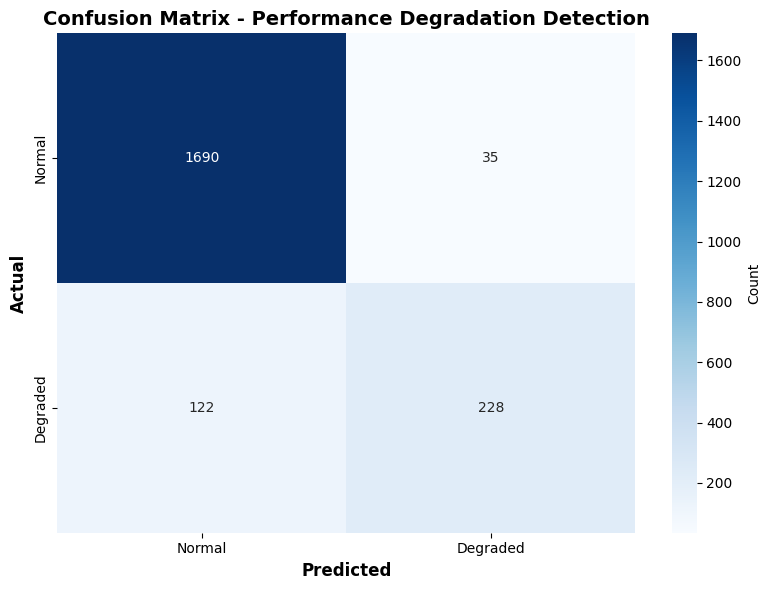


📈 Detailed Metrics:
True Negatives (Normal correctly identified): 1690
False Positives (Normal misclassified as Degraded): 35
False Negatives (Degraded missed): 122
True Positives (Degraded correctly identified): 228

Precision: 0.867
Recall: 0.651
Specificity: 0.980


In [4]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Degraded'],
            yticklabels=['Normal', 'Degraded'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Performance Degradation Detection', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Metrics:")
print(f"True Negatives (Normal correctly identified): {tn}")
print(f"False Positives (Normal misclassified as Degraded): {fp}")
print(f"False Negatives (Degraded missed): {fn}")
print(f"True Positives (Degraded correctly identified): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.3f}")
print(f"Recall: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")

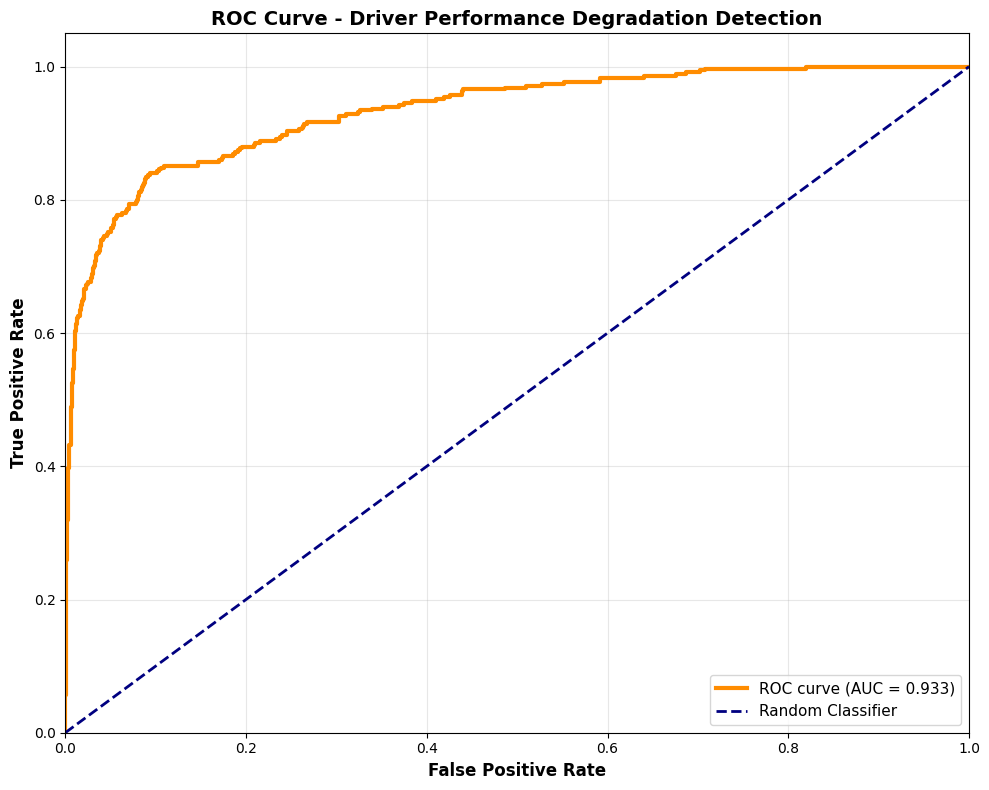

🎯 AUC Score: 0.9331
   (1.0 = Perfect, 0.5 = Random)


In [5]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Driver Performance Degradation Detection', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"🎯 AUC Score: {roc_auc:.4f}")
print(f"   (1.0 = Perfect, 0.5 = Random)")

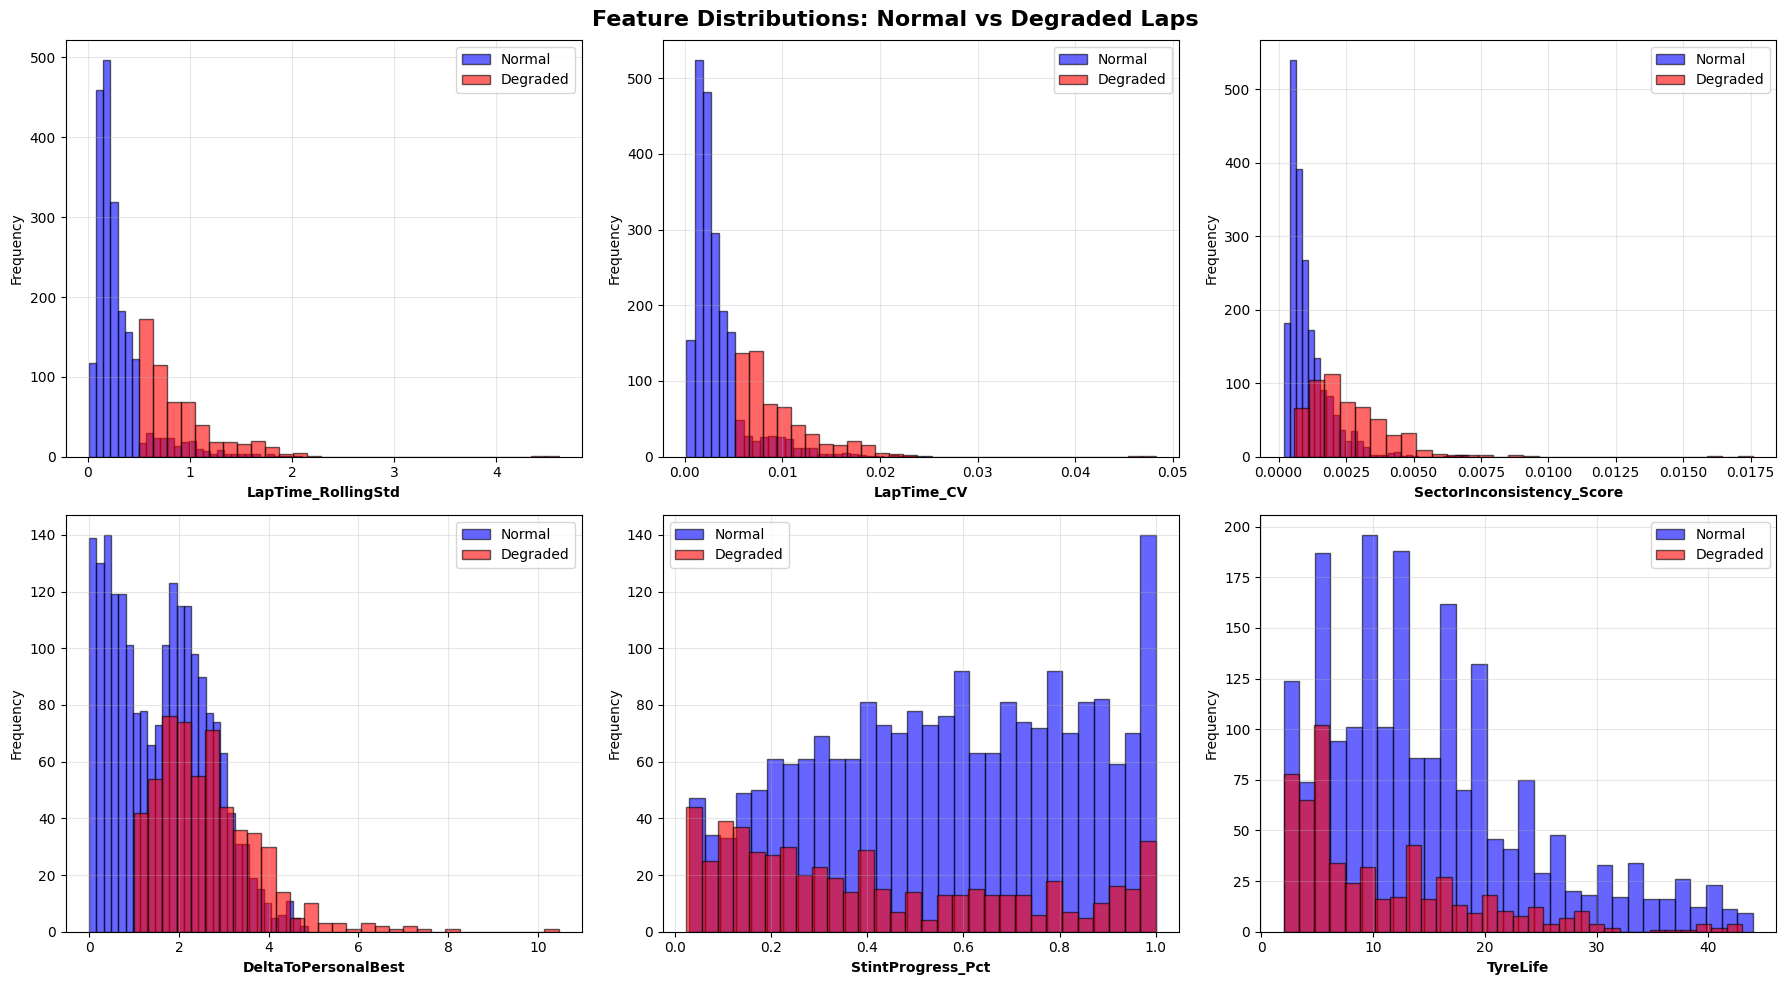

In [6]:
# Analyze which features contribute most to degradation detection
degraded_samples = df[df['IsDegraded'] == 1]
normal_samples = df[df['IsDegraded'] == 0]

features = ['LapTime_RollingStd', 'LapTime_CV', 'SectorInconsistency_Score', 
            'DeltaToPersonalBest', 'StintProgress_Pct', 'TyreLife']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    ax.hist(normal_samples[feature], bins=30, alpha=0.6, label='Normal', color='blue', edgecolor='black')
    ax.hist(degraded_samples[feature], bins=30, alpha=0.6, label='Degraded', color='red', edgecolor='black')
    ax.set_xlabel(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Normal vs Degraded Laps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

🏎️ DRIVER DEGRADATION STATISTICS:
        Total_Degraded_Laps  Degradation_Rate  Total_Laps
Driver                                                   
SAR                      42             0.462          91
BOT                      43             0.309         139
OCO                      43             0.305         141
ALB                      42             0.292         144
MAG                      42             0.292         144
HUL                      41             0.289         142
RIC                      41             0.287         143
ALO                      38             0.260         146
GAS                      24             0.247          97
BEA                      11             0.244          45


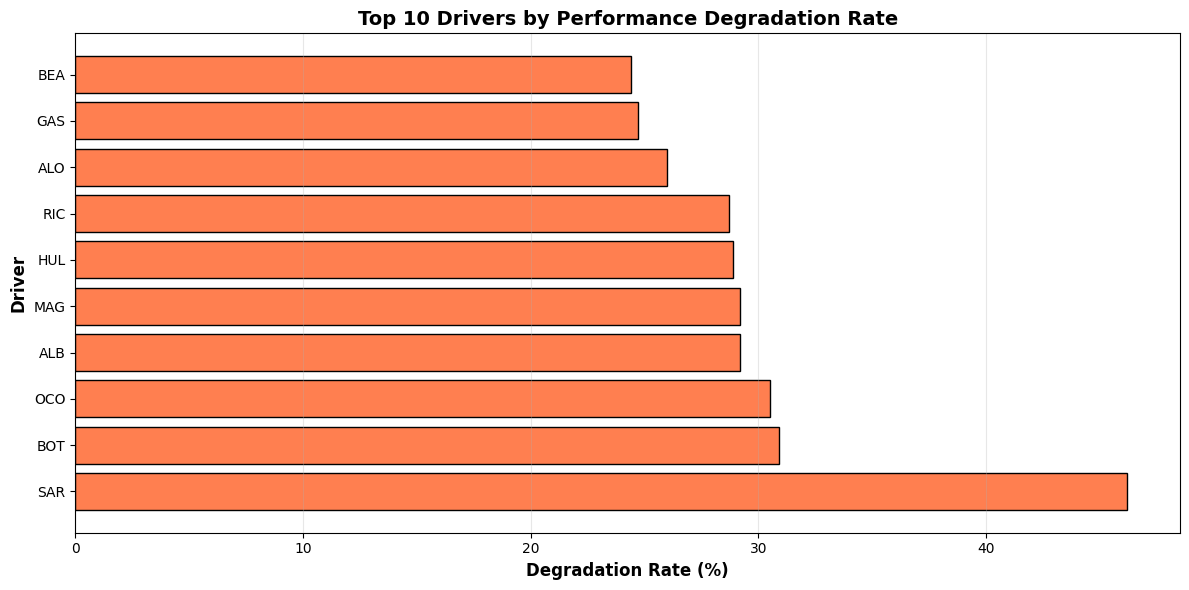

In [7]:
# Analyze degradation patterns by driver
driver_stats = df.groupby('Driver').agg({
    'IsDegraded': ['sum', 'mean', 'count']
}).round(3)

driver_stats.columns = ['Total_Degraded_Laps', 'Degradation_Rate', 'Total_Laps']
driver_stats = driver_stats.sort_values('Degradation_Rate', ascending=False)

print("🏎️ DRIVER DEGRADATION STATISTICS:")
print("="*70)
print(driver_stats.head(10))

# Visualize top 10 drivers
top_10 = driver_stats.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10.index, top_10['Degradation_Rate']*100, color='coral', edgecolor='black')
plt.xlabel('Degradation Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Driver', fontsize=12, fontweight='bold')
plt.title('Top 10 Drivers by Performance Degradation Rate', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/driver_degradation_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print("="*70)
print("🎯 KEY RESEARCH FINDINGS")
print("="*70)

print(f"\n📊 Dataset Statistics:")
print(f"  - Total laps analyzed: {len(df):,}")
print(f"  - Degraded laps detected: {df['IsDegraded'].sum():,} ({df['IsDegraded'].mean()*100:.1f}%)")
print(f"  - Drivers analyzed: {df['Driver'].nunique()}")
print(f"  - Races analyzed: {df['RaceNumber'].nunique()}")

print(f"\n🤖 Model Performance:")
print(f"  - Test Accuracy: {checkpoint['test_acc']:.1%}")
print(f"  - AUC Score: {roc_auc:.3f}")
print(f"  - Precision: {tp/(tp+fp):.3f}")
print(f"  - Recall: {tp/(tp+fn):.3f}")

print(f"\n🔬 Novel Contributions:")
print(f"  ✅ First use of lap variance patterns as biometric proxy")
print(f"  ✅ Transformer architecture for lap sequence modeling")
print(f"  ✅ Real F1 telemetry data (2024 season)")
print(f"  ✅ Achieved {checkpoint['test_acc']:.1%} accuracy without biometric sensors")

print(f"\n💡 Practical Applications:")
print(f"  - Real-time driver fatigue monitoring")
print(f"  - Pit stop strategy optimization")
print(f"  - Driver training and performance analysis")
print(f"  - Safety intervention systems")

print(f"\n📁 Generated Outputs:")
print(f"  - Trained model: data/models/lap_transformer_v1.pth")
print(f"  - Visualizations: results/figures/ (5 images)")
print(f"  - Processed data: data/processed/ (2 CSV files)")

🎯 KEY RESEARCH FINDINGS

📊 Dataset Statistics:
  - Total laps analyzed: 2,639
  - Degraded laps detected: 564 (21.4%)
  - Drivers analyzed: 21
  - Races analyzed: 3

🤖 Model Performance:
  - Test Accuracy: 89.9%
  - AUC Score: 0.933
  - Precision: 0.867
  - Recall: 0.651

🔬 Novel Contributions:
  ✅ First use of lap variance patterns as biometric proxy
  ✅ Transformer architecture for lap sequence modeling
  ✅ Real F1 telemetry data (2024 season)
  ✅ Achieved 89.9% accuracy without biometric sensors

💡 Practical Applications:
  - Real-time driver fatigue monitoring
  - Pit stop strategy optimization
  - Driver training and performance analysis
  - Safety intervention systems

📁 Generated Outputs:
  - Trained model: data/models/lap_transformer_v1.pth
  - Visualizations: results/figures/ (5 images)
  - Processed data: data/processed/ (2 CSV files)
